In [1]:
print('hello')

hello


In [2]:
! pip install nltk

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# worldcloud
import random
from wordcloud import WordCloud


In [4]:
# Download NLTK resources (only needed once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\louis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\louis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\louis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
# retrieving the datasets we used for the last notebook

raw_path = '../data/olist_datasets/'

df_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')


# I - Sentiment analysis of customer reviews

## A - Reminders on the Review dataframe

In [6]:
# checking that df_order_reviews is loaded

df_order_reviews.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


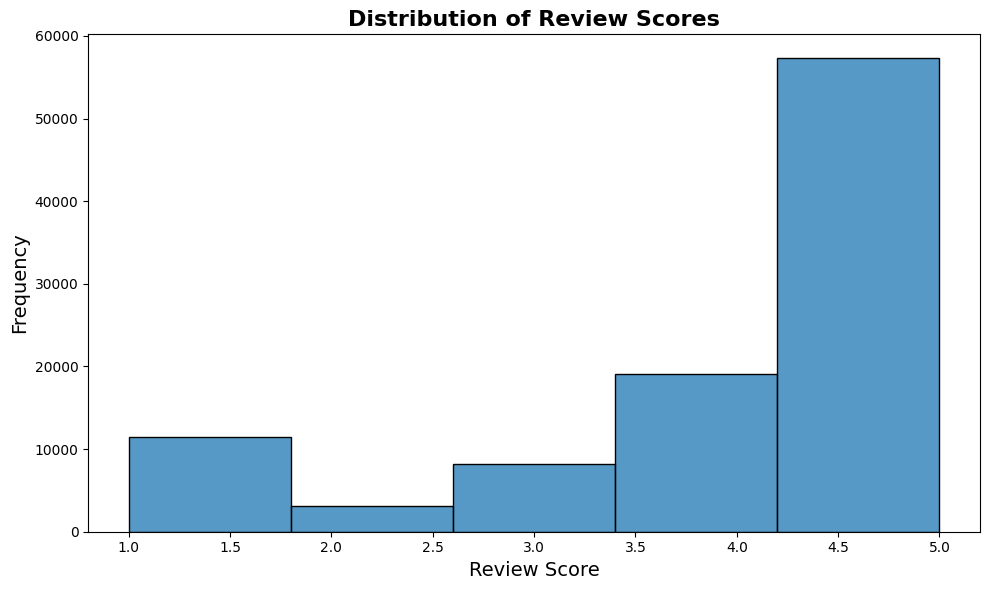

In [7]:
# Create a distribution plot (dist plot) with seaborn on the review score

# "professional" colors
colors = ['#2C3E50', '#E74C3C', '#ECF0F1', '#3498DB', '#2ECC71', '#F1C40F', '#9B59B6']

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with seaborn
ax = sns.histplot(data=df_order_reviews, 
            x='review_score',
            bins=5,
            edgecolor='black',
            stat='count')

# Customizing the plot
plt.title('Distribution of Review Scores', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Ajuster les marges
plt.tight_layout()

# Show the plot
plt.show();


In [8]:
# Check for missing values in review comments
missing_comments = df_order_reviews['review_comment_message'].isnull().sum()
print(f"Missing review comments: {missing_comments}")

# Filter out rows with missing comments
reviews_with_comments = df_order_reviews.dropna(subset=['review_comment_message']).copy()
print(f"Reviews with comments: {len(reviews_with_comments)}")


Missing review comments: 58247
Reviews with comments: 40977


In [9]:
# Create a new column to categorize reviews as positive, neutral, or negative
def categorize_sentiment(score):
    '''if score is >=4 then good, if <3 then bad, else neutral'''
    if score >= 4:
        return 'positive'
    elif score < 3:
        return 'negative'
    else:
        return 'neutral'

# apply the function to the dataframe
reviews_with_comments['sentiment'] = reviews_with_comments['review_score'].apply(categorize_sentiment)
print(reviews_with_comments['sentiment'].value_counts())


sentiment
positive    26530
negative    10890
neutral      3557
Name: count, dtype: int64


C:\Users\louis\AppData\Local\Temp\ipykernel_9000\2645696636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,


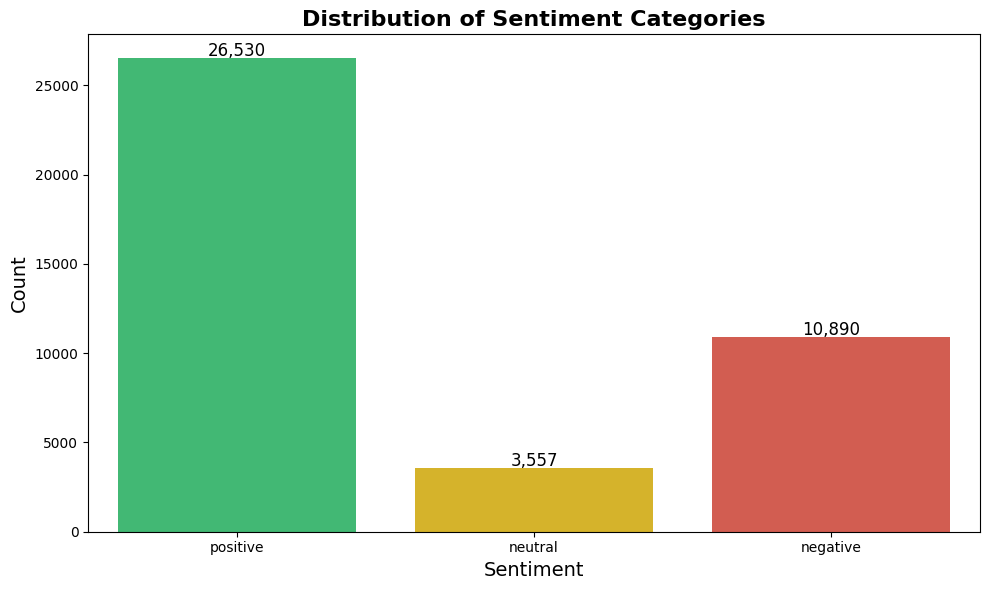

In [10]:
# Visualize the sentiment distribution - how many reviews by categories?
plt.figure(figsize=(10, 6))
sentiment_counts = reviews_with_comments['sentiment'].value_counts()
ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, 
                 palette=['#2ECC71', '#F1C40F', '#E74C3C'],
                 order=['positive', 'neutral', 'negative'])

plt.title('Distribution of Sentiment Categories', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add count labels on bars
for i, v in enumerate(sentiment_counts.reindex(['positive', 'neutral', 'negative']).values):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


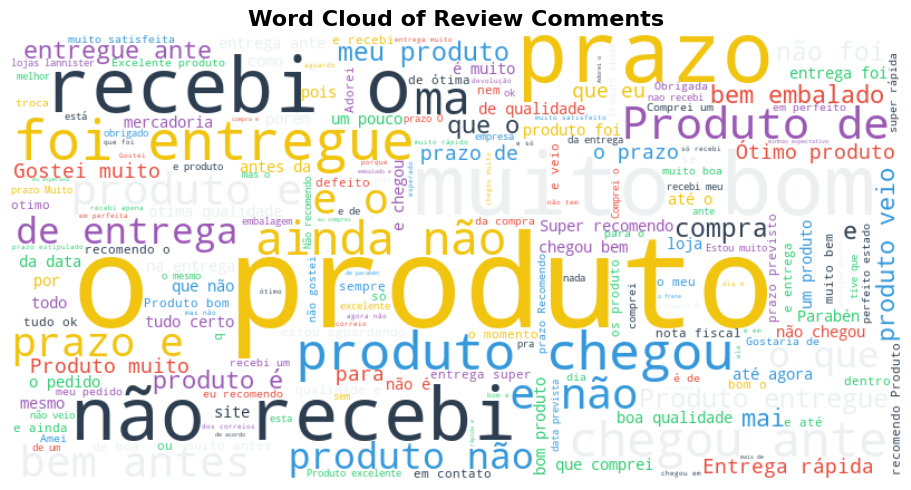

In [11]:
## Wordcloud

# Create a wordcloud on orders with negative reviews only

# Define a color function
def color_func(word, font_size, position, orientation, random_state=42, **kwargs):
    return random.choice(colors)

# Example: Word cloud from review comments
plt.figure(figsize=(10, 5))

# every order
#wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(' '.join(df['review_comment_message'].dropna()))

# only negative reviews
#reviews_with_negative_comments = reviews_with_comments[reviews_with_comments.review_score < 3]
wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func)
wordcloud.generate(' '.join(reviews_with_comments['review_comment_message'].dropna()))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title('Word Cloud of Review Comments', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


## B - Text Preprocessing and conversion to numerical features

### 1 - Cleaning a small sample of the data and looking at the results

In [12]:
# create a new sample dataframe, that will be a sample of df_order_reviews
# which only have non null review_comment_messages
# which only contains review_id, review_score, review_comment_message

sample_df = df_order_reviews[df_order_reviews['review_comment_message'].notna()][['review_id', 'review_score', 'review_comment_message']].head(20).copy()
sample_df


,review_id,review_score,review_comment_message
3,e64fb393e7b32834bb789ff8bb30750e,5,Recebi bem antes do prazo estipulado.
4,f7c4243c7fe1938f181bec41a392bdeb,5,Parabéns lojas lannister adorei comprar pela I...
9,8670d52e15e00043ae7de4c01cc2fe06,4,aparelho eficiente. no site a marca do aparelh...
12,4b49719c8a200003f700d3d986ea1a19,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,3948b09f7c818e2d86c9a546758b2335,5,"Vendedor confiável, produto ok e entrega antes..."
16,9314d6f9799f5bfba510cc7bcd468c01,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
19,373cbeecea8286a2b66c97b1b157ec46,1,Péssimo
22,d21bbc789670eab777d27372ab9094cc,5,Loja nota 10
24,0e0190b9db53b689b285d3f3916f8441,5,obrigado pela atençao amim dispensada
27,fe3db7c069d694bab50cc43463f91608,5,A compra foi realizada facilmente.\r\nA entreg...


In [13]:
# create a new comment_clean column which makes the text LOWER (no uppercases)

sample_df['comment_clean'] = sample_df['review_comment_message'].str.lower()
sample_df[['review_comment_message', 'comment_clean']].head()

,review_comment_message,comment_clean
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","mas um pouco ,travando...pelo valor ta boa.\r\n"
15,"Vendedor confiável, produto ok e entrega antes...","vendedor confiável, produto ok e entrega antes..."


In [14]:
# remove the special characters using a simple regex function

sample_df['comment_clean'] = sample_df['comment_clean'].apply(lambda x: re.sub(r'[^a-záàâãéèêíïóôõöúçñ\s]', '', x))
sample_df[['review_comment_message', 'comment_clean']].head()


,review_comment_message,comment_clean
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado
4,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente no site a marca do aparelho...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",mas um pouco travandopelo valor ta boa\r\n
15,"Vendedor confiável, produto ok e entrega antes...",vendedor confiável produto ok e entrega antes ...


In [15]:
# tokenize the text - meaning, isolate all words into a list, using the NLTK library, and another column - comment_clean_tokenized

sample_df['comment_clean_tokenized'] = sample_df['comment_clean'].apply(lambda x: nltk.word_tokenize(x))
sample_df[['comment_clean', 'comment_clean_tokenized']].head()

,comment_clean,comment_clean_tokenized
3,recebi bem antes do prazo estipulado,"[recebi, bem, antes, do, prazo, estipulado]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ..."
9,aparelho eficiente no site a marca do aparelho...,"[aparelho, eficiente, no, site, a, marca, do, ..."
12,mas um pouco travandopelo valor ta boa\r\n,"[mas, um, pouco, travandopelo, valor, ta, boa]"
15,vendedor confiável produto ok e entrega antes ...,"[vendedor, confiável, produto, ok, e, entrega,..."


In [16]:
# then remove the stopwords using the portuguese library from NLTK

stop_words = set(stopwords.words('portuguese'))
sample_df['comment_clean_no_stopwords'] = sample_df['comment_clean_tokenized'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)
sample_df[['comment_clean_tokenized', 'comment_clean_no_stopwords']].head()


,comment_clean_tokenized,comment_clean_no_stopwords
3,"[recebi, bem, antes, do, prazo, estipulado]","[recebi, bem, antes, prazo, estipulado]"
4,"[parabéns, lojas, lannister, adorei, comprar, ...","[parabéns, lojas, lannister, adorei, comprar, ..."
9,"[aparelho, eficiente, no, site, a, marca, do, ...","[aparelho, eficiente, site, marca, aparelho, i..."
12,"[mas, um, pouco, travandopelo, valor, ta, boa]","[pouco, travandopelo, valor, ta, boa]"
15,"[vendedor, confiável, produto, ok, e, entrega,...","[vendedor, confiável, produto, ok, entrega, an..."


In [17]:
# Use stemming to shorten the words as much as possible using another column - comment_clean_stemmed

stemmer = PorterStemmer()

sample_df['comment_clean_stemmed'] = sample_df['comment_clean_no_stopwords'].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)
sample_df[['comment_clean_no_stopwords', 'comment_clean_stemmed']].head()


,comment_clean_no_stopwords,comment_clean_stemmed
3,"[recebi, bem, antes, prazo, estipulado]","[recebi, bem, ant, prazo, estipulado]"
4,"[parabéns, lojas, lannister, adorei, comprar, ...","[parabén, loja, lannist, adorei, comprar, inte..."
9,"[aparelho, eficiente, site, marca, aparelho, i...","[aparelho, eficient, site, marca, aparelho, im..."
12,"[pouco, travandopelo, valor, ta, boa]","[pouco, travandopelo, valor, ta, boa]"
15,"[vendedor, confiável, produto, ok, entrega, an...","[vendedor, confiável, produto, ok, entrega, an..."


### 2 - Text preprocessing

In [18]:
# Define a function to clean and preprocess text
def preprocess_text(text):
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()
        
        # Remove special characters, numbers, and punctuation
        text = re.sub(r'[^a-záàâãéèêíïóôõöúçñ\s]', '', text)
        
        # Tokenize the text
        tokens = nltk.word_tokenize(text)
        
        # Remove stopwords (Portuguese)
        stop_words = set(stopwords.words('portuguese'))
        tokens = [word for word in tokens if word not in stop_words]
        
        # Stemming
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(word) for word in tokens]
        
        # Join tokens back into a string
        processed_text = ' '.join(tokens)
        
        return processed_text
    else:
        return ''  # Return empty string for non-string inputs


In [19]:
# Apply preprocessing to the review comments

reviews_with_comments['processed_comment'] = reviews_with_comments['review_comment_message'].apply(preprocess_text)
print(f"Preprocessing complete. {len(reviews_with_comments)} reviews processed.")


Preprocessing complete. 40977 reviews processed.


In [20]:
# Display a sample of original and processed comments

reviews_with_comments[['review_comment_message', 'processed_comment', 'sentiment']].head(10)


,review_comment_message,processed_comment,sentiment
3,Recebi bem antes do prazo estipulado.,recebi bem ant prazo estipulado,positive
4,Parabéns lojas lannister adorei comprar pela I...,parabén loja lannist adorei comprar internet s...,positive
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficient site marca aparelho impresso...,positive
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travandopelo valor ta boa,positive
15,"Vendedor confiável, produto ok e entrega antes...",vendedor confiável produto ok entrega ant prazo,positive
16,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",gostaria saber sempr recebi compra agora decpcion,negative
19,Péssimo,péssimo,negative
22,Loja nota 10,loja nota,positive
24,obrigado pela atençao amim dispensada,obrigado atençao amim dispensada,positive
27,A compra foi realizada facilmente.\r\nA entreg...,compra realizada facilment entrega efetuada an...,positive


### 3 - Final preparation steps

In [21]:
# Split the data into training and testing sets

X = reviews_with_comments['processed_comment']
y = reviews_with_comments['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining set sentiment distribution:\n{y_train.value_counts()}")


Training set size: 32781
Testing set size: 8196

Training set sentiment distribution:
sentiment
positive    21224
negative     8712
neutral      2845
Name: count, dtype: int64


## C - Building a Simple Naive Bayes Model

In [22]:
# Use CountVectorizer to convert text to a matrix of token counts
count_vectorizer = CountVectorizer(max_features=5000)  # Limit to top 5000 features

X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

print(f"Shape of training features: {X_train_counts.shape}")
print(f"Shape of testing features: {X_test_counts.shape}")


Shape of training features: (32781, 5000)
Shape of testing features: (8196, 5000)


In [23]:
# understanding what we just did

# Some computation to find an interesting extract to look at
word_freq = X_train_counts.sum(axis=0).A1  # converting the matrix into an A1 array
word_indices = word_freq.argsort()[-10:][::-1]  # 10 most frequent words
top_feature_names = [count_vectorizer.get_feature_names_out()[i] for i in word_indices]

# creating a sample with 10 most frequent words + 5 first reviews
df_sample = pd.DataFrame(
    X_train_counts[:5, word_indices].toarray(),
    columns=top_feature_names
)

print("Displaying an extract of the bag-of-words matrix (5 first comments, 10 most frequent words):")
df_sample

Displaying an extract of the bag-of-words matrix (5 first comments, 10 most frequent words):


,produto,prazo,entrega,ant,chegou,recebi,bom,recomendo,entregu,veio
0,0,0,1,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,1
3,2,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


In [24]:
# Train a Naive Bayes classifier
nb_classifier = MultinomialNB()

nb_classifier.fit(X_train_counts, y_train)
print("Naive Bayes classifier trained successfully!")


Naive Bayes classifier trained successfully!


In [25]:
# Make predictions on the test set

y_pred_nb = nb_classifier.predict(X_test_counts)
print("Predictions made successfully!")


Predictions made successfully!


In [26]:
# Evaluate the model

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")


Naive Bayes Accuracy: 0.8173


In [27]:
# Display classification report
print("Classification Report:\n")

print(classification_report(y_test, y_pred_nb))


Classification Report:

              precision    recall  f1-score   support

    negative       0.76      0.78      0.77      2178
     neutral       0.26      0.20      0.23       712
    positive       0.90      0.91      0.91      5306

    accuracy                           0.82      8196
   macro avg       0.64      0.63      0.63      8196
weighted avg       0.81      0.82      0.81      8196



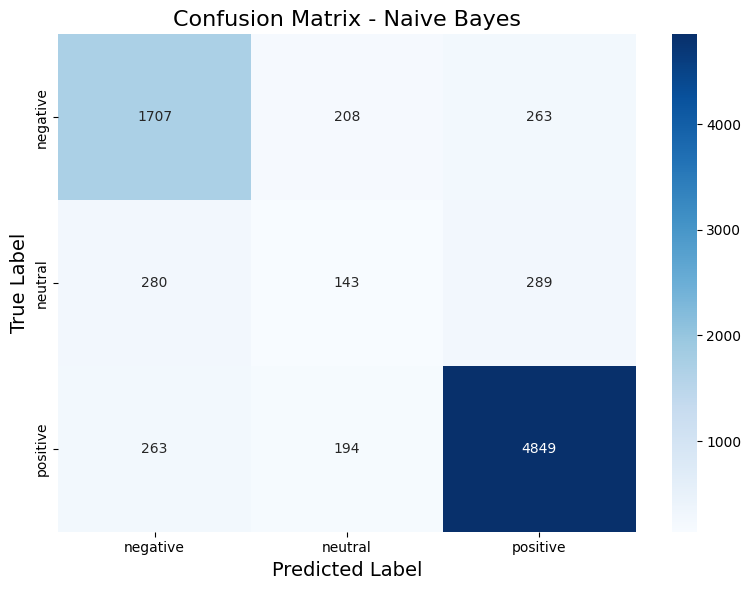

In [28]:
# Create and display confusion matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_classifier.classes_,
            yticklabels=nb_classifier.classes_)
plt.title('Confusion Matrix - Naive Bayes', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()


## D - Building a More Advanced Model - Logistic Regression with TF-IDF

In [29]:
# Use TF-IDF Vectorizer for better feature extraction
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of training features: {X_train_tfidf.shape}")
print(f"Shape of testing features: {X_test_tfidf.shape}")


Shape of training features: (32781, 5000)
Shape of testing features: (8196, 5000)


In [30]:
# Train a Logistic Regression classifier
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)

lr_classifier.fit(X_train_tfidf, y_train)
print("Logistic Regression classifier trained successfully!")


Logistic Regression classifier trained successfully!


In [31]:
# Make predictions on the test set

y_pred_lr = lr_classifier.predict(X_test_tfidf)

# Evaluate the model

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")


Logistic Regression Accuracy: 0.8400


In [32]:
# Display classification report

print("Classification Report - Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))


Classification Report - Logistic Regression:

              precision    recall  f1-score   support

    negative       0.76      0.85      0.80      2178
     neutral       0.32      0.05      0.09       712
    positive       0.89      0.94      0.91      5306

    accuracy                           0.84      8196
   macro avg       0.66      0.61      0.60      8196
weighted avg       0.80      0.84      0.81      8196



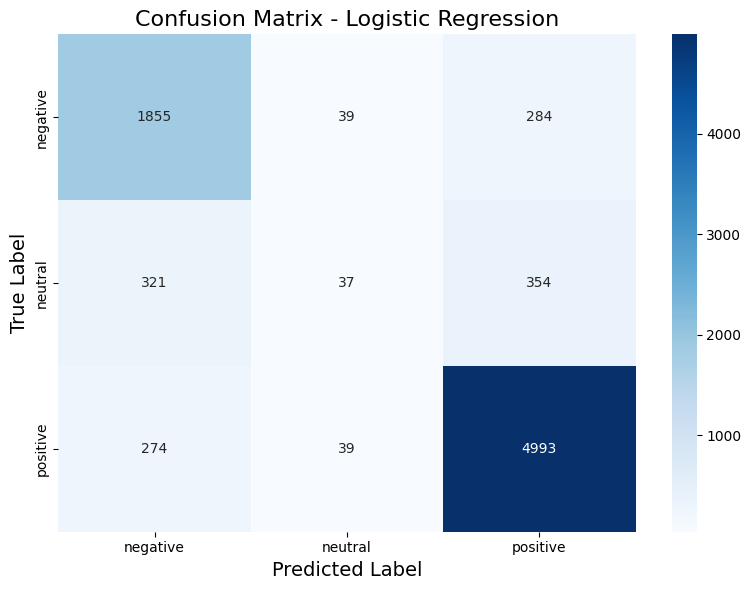

In [33]:
# Create and display confusion matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_classifier.classes_, 
            yticklabels=lr_classifier.classes_)
plt.title('Confusion Matrix - Logistic Regression', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show();


In [34]:
# Get feature importance from Logistic Regression model
feature_importance = pd.DataFrame({
    'feature': tfidf_vectorizer.get_feature_names_out(),
    'importance': lr_classifier.coef_.mean(axis=0)
})

# Sort by absolute importance
feature_importance['abs_importance'] = abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('abs_importance', ascending=False)


In [35]:
# Display most important positive and negative words
print("Top 10 words associated with positive sentiment:")
positive_features = feature_importance.sort_values('importance', ascending=False).head(10)
print(positive_features[['feature', 'importance']])

print("\nTop 10 words associated with negative sentiment:")
negative_features = feature_importance.sort_values('importance', ascending=True).head(10)
print(negative_features[['feature', 'importance']])


Top 10 words associated with positive sentiment:
          feature    importance
2895  maravilhoso  7.845576e-15
4737         tudo  7.697546e-15
3732        prazo  7.179442e-15
1716     embalado  6.661338e-15
1332    demorando  6.624331e-15
514           bom  5.995204e-15
1146      correta  5.329071e-15
205          amei  5.329071e-15
484           bem  5.181041e-15
2721         liga  4.958996e-15

Top 10 words associated with negative sentiment:
          feature    importance
437         baixa -1.036208e-14
1999     excelent -1.021405e-14
2748        lindo -8.585725e-15
4629       testei -6.957398e-15
3529     perfeito -6.809368e-15
4142       recebi -6.661338e-15
3899      produto -6.069219e-15
693         certo -5.477100e-15
503           boa -5.329071e-15
1147  corretament -5.255056e-15


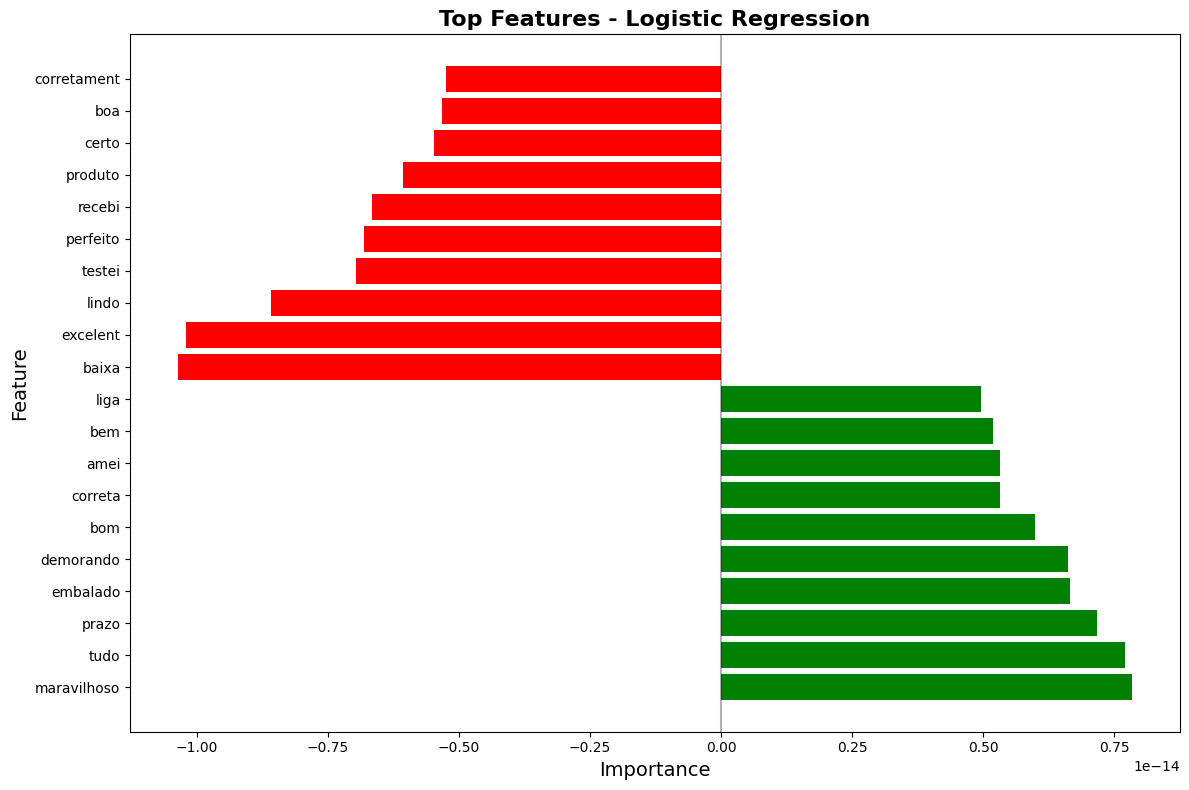

In [36]:
# Visualize top features
plt.figure(figsize=(12, 8))

top_features = pd.concat([positive_features.head(15), negative_features.head(15)])

colors = ['green' if x > 0 else 'red' for x in top_features['importance']]

plt.barh(top_features['feature'], top_features['importance'], color=colors)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top Features - Logistic Regression', fontsize=16, fontweight='bold')

plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show();


## E - Rainforest model

In [37]:
# Start a timer to understand how long the model will last
import time
start_time = time.time()

# Create a random forest model, while limiting the number of trees to make sure it doesn't run for too long
rf_classifier = RandomForestClassifier(
    n_estimators=100,     # number of trees in the forest
    max_depth=None,       # trees can be as deep (long) as possible
    min_samples_split=2,  # minimum split number to build a node (2 trees min to build a node)
    random_state=42,
    n_jobs=-1             # use all possible resources
)

# Use the model on the X_train TF-IDF data (same than the logistic regression)
rf_classifier.fit(X_train_tfidf, y_train)

# Predictions on the test set
y_pred_rf = rf_classifier.predict(X_test_tfidf)

# Compute execution time
training_time = time.time() - start_time
print(f"Random Forest training: {training_time:.2f} seconds")


Random Forest training: 6.82 seconds


In [38]:
# Evaluate the model

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")



Random Forest Accuracy: 0.8311


In [39]:
# Display the classification report

print("Classification Report - Random Forest:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report - Random Forest:

              precision    recall  f1-score   support

    negative       0.73      0.85      0.78      2178
     neutral       0.33      0.03      0.05       712
    positive       0.88      0.93      0.91      5306

    accuracy                           0.83      8196
   macro avg       0.65      0.60      0.58      8196
weighted avg       0.79      0.83      0.80      8196



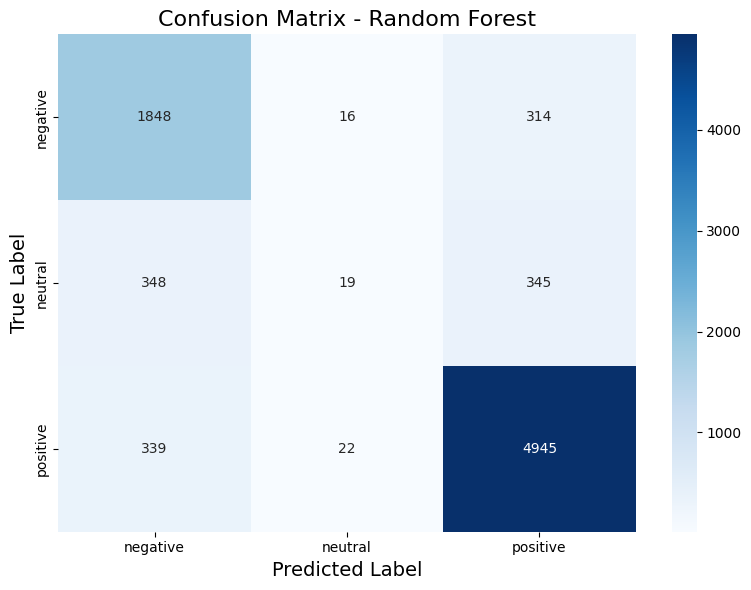

In [40]:
# Create and display the confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_classifier.classes_,
            yticklabels=rf_classifier.classes_)
plt.title('Confusion Matrix - Random Forest', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()


In [41]:
# get the feature importance of the Random Forest model

rf_feature_importance = pd.DataFrame({
    'feature': tfidf_vectorizer.get_feature_names_out(),
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important features for Random Forest:")
rf_feature_importance.head(20)


Top 20 most important features for Random Forest:


,feature,importance
4142,recebi,0.036575
3899,produto,0.023951
921,comprei,0.023157
235,ant,0.021796
3732,prazo,0.020832
514,bom,0.016787
148,ainda,0.015371
4181,recomendo,0.013072
4836,veio,0.012187
3135,nao,0.012022


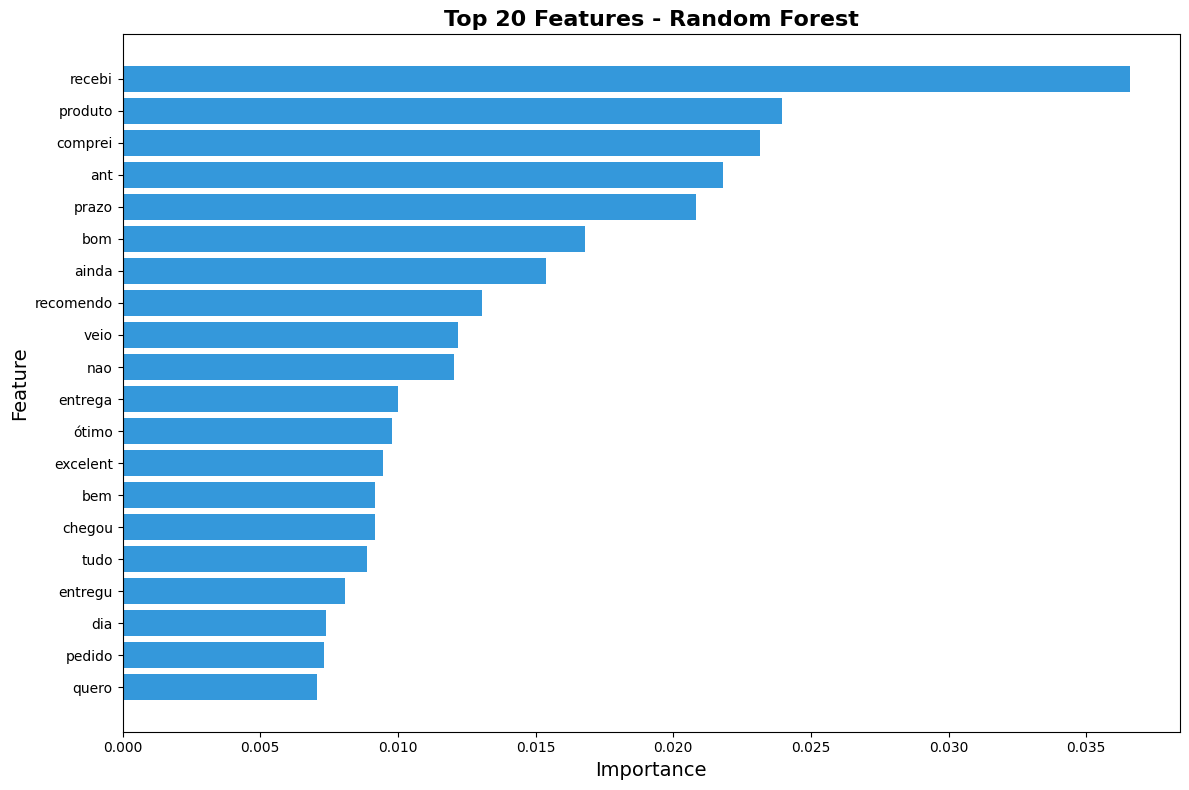

In [42]:
# Visualize the most important features

plt.figure(figsize=(12, 8))
top_rf_features = rf_feature_importance.head(20)
plt.barh(top_rf_features['feature'], top_rf_features['importance'], color='#3498DB')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top 20 Features - Random Forest', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()


## F - Model comparison

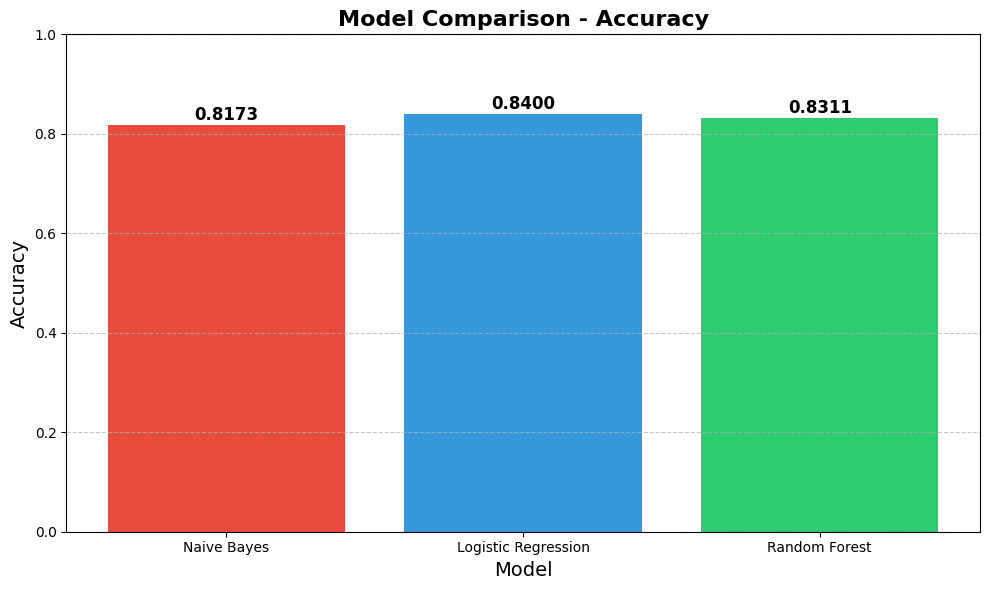

In [43]:

# Compare the performances of the 3 models
models = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
accuracies = [accuracy_nb, accuracy_lr, accuracy_rf]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#E74C3C', '#3498DB', '#2ECC71'])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.ylim(0, 1)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Model Comparison - Accuracy', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


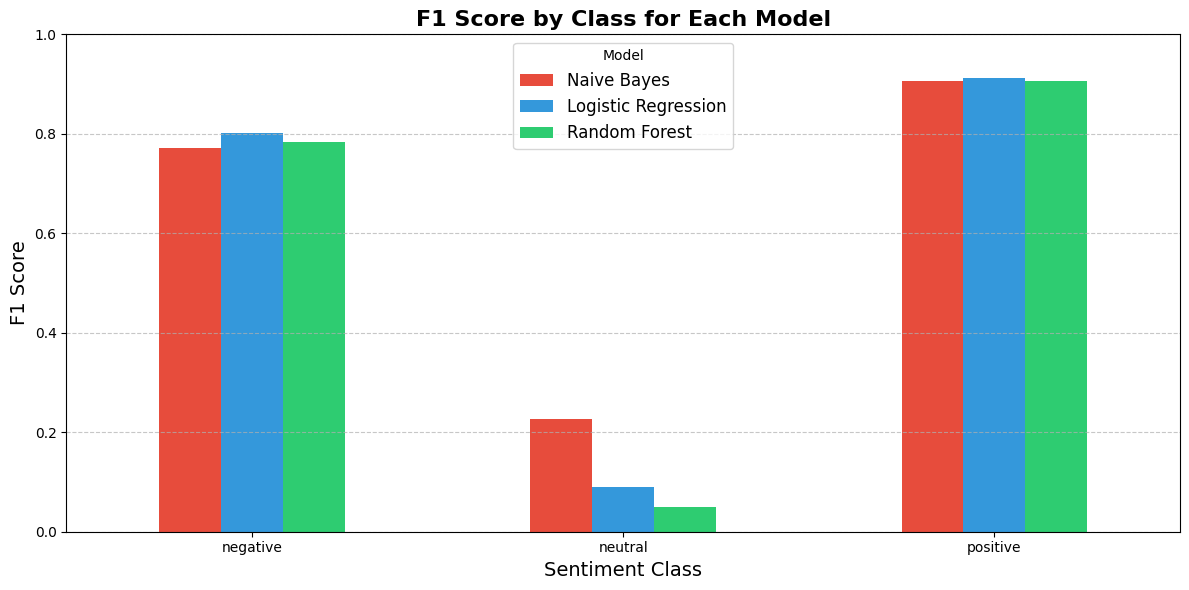

In [44]:
# Compute the F1 score by class (f1_nb, f1_lr, f1_rf)

f1_nb = f1_score(y_test, y_pred_nb, average=None, labels=rf_classifier.classes_)
f1_lr = f1_score(y_test, y_pred_lr, average=None, labels=rf_classifier.classes_)
f1_rf = f1_score(y_test, y_pred_rf, average=None, labels=rf_classifier.classes_)

# Create a dataframe for the visualization
f1_df = pd.DataFrame({
    'Naive Bayes': f1_nb,
    'Logistic Regression': f1_lr,
    'Random Forest': f1_rf
}, index=rf_classifier.classes_)

# Visualize F1 scores by classes

f1_df.plot(kind='bar', figsize=(12, 6), color=['#E74C3C', '#3498DB', '#2ECC71'])
plt.xlabel('Sentiment Class', fontsize=14)
plt.ylabel('F1 Score', fontsize=14)
plt.title('F1 Score by Class for Each Model', fontsize=16, fontweight='bold')
plt.legend(title='Model', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## G - Example use case: predicting new comments

In [45]:
# Create a function to predict sentiment for new reviews
def predict_sentiment(review_text, vectorizer, model):
    # Preprocess the review
    processed_review = preprocess_text(review_text)
    # Vectorize the review
    review_vector = vectorizer.transform([processed_review])
    # Predict the sentiment
    sentiment = model.predict(review_vector)[0]
    # Get prediction probabilities
    proba = model.predict_proba(review_vector)[0]
    # Return the sentiment and confidence
    return sentiment, proba


In [46]:
# Example reviews to test
example_reviews = [
    "O produto é excelente, superou minhas expectativas!",  # Positive
    "Entrega foi feita no prazo, mas o produto não é tão bom quanto esperava.",  # Neutral
    "Péssimo produto, chegou com defeito e o atendimento ao cliente foi horrível."  # Negative
]

# Predict sentiment for example reviews
print("Predicting sentiment for example reviews:")
for i, review in enumerate(example_reviews):
    sentiment, proba = predict_sentiment(review, tfidf_vectorizer, lr_classifier)
    print(f"\nExample {i+1}: {review}")
    print(f"Predicted sentiment: {sentiment}")
    print(f"Confidence: {max(proba):.2f}")
    print(f"Probabilities: {dict(zip(lr_classifier.classes_, proba))}")
    

Predicting sentiment for example reviews:

Example 1: O produto é excelente, superou minhas expectativas!
Predicted sentiment: positive
Confidence: 0.99
Probabilities: {'negative': np.float64(0.0024415262984835004), 'neutral': np.float64(0.002950154624781881), 'positive': np.float64(0.9946083190767345)}

Example 2: Entrega foi feita no prazo, mas o produto não é tão bom quanto esperava.
Predicted sentiment: positive
Confidence: 0.45
Probabilities: {'negative': np.float64(0.11241266387836364), 'neutral': np.float64(0.43818527836718396), 'positive': np.float64(0.4494020577544524)}

Example 3: Péssimo produto, chegou com defeito e o atendimento ao cliente foi horrível.
Predicted sentiment: negative
Confidence: 0.97
Probabilities: {'negative': np.float64(0.9701190013872788), 'neutral': np.float64(0.010137830448426956), 'positive': np.float64(0.019743168164294226)}


# II - Delivery prediction (bonus)

## A - Data preparation

In [47]:
# We'll use the merged dataframe from previous parts
# If not already done, we need to merge the necessary dataframes

# Load required datasets (reload to avoid conflicts with previous variables)
df_orders_2 = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_customers_2 = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_order_items_2 = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_products_2 = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers_2 = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')

# Merge datasets
df = df_orders_2.merge(df_customers_2, on='customer_id')
df = df.merge(df_order_items_2, on='order_id')
df = df.merge(df_products_2, on='product_id')
df = df.merge(df_sellers_2, on='seller_id')

print(f"DataFrame shape: {df.shape}")
df.head()


DataFrame shape: (112650, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752,mogi das cruzes,SP


In [48]:
# Convert date columns to datetime
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col])


# Calculate delivery time in days
df['actual_delivery_time'] = (df['order_delivered_customer_date'] - 
                             df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Calculate if the delivery was delayed (1) or not (0)
df['estimated_delivery_time'] = (df['order_estimated_delivery_date'] - 
                                df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
df['is_delayed'] = (df['actual_delivery_time'] > df['estimated_delivery_time']).astype(int)

# Calculate time to carrier in days
df['time_to_carrier'] = (df['order_delivered_carrier_date'] - 
                        df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Filter out rows with missing delivery dates (canceled orders, etc.)
delivery_df = df.dropna(subset=['order_delivered_customer_date', 'order_delivered_carrier_date'])

delivery_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,actual_delivery_time,estimated_delivery_time,is_delayed,time_to_carrier
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350,maua,SP,8.436574,15.544063,0,2.373924
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570,belo horizonte,SP,13.782037,19.137766,0,1.742627
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840,guariba,SP,9.394213,26.639711,0,0.216100
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,30.0,10.0,20.0,31842,belo horizonte,MG,13.208750,26.188819,0,3.758252
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,51.0,15.0,15.0,8752,mogi das cruzes,SP,2.873877,12.112049,0,0.936053


C:\Users\louis\AppData\Local\Temp\ipykernel_9000\1813984735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_delayed', data=delivery_df, palette='viridis')


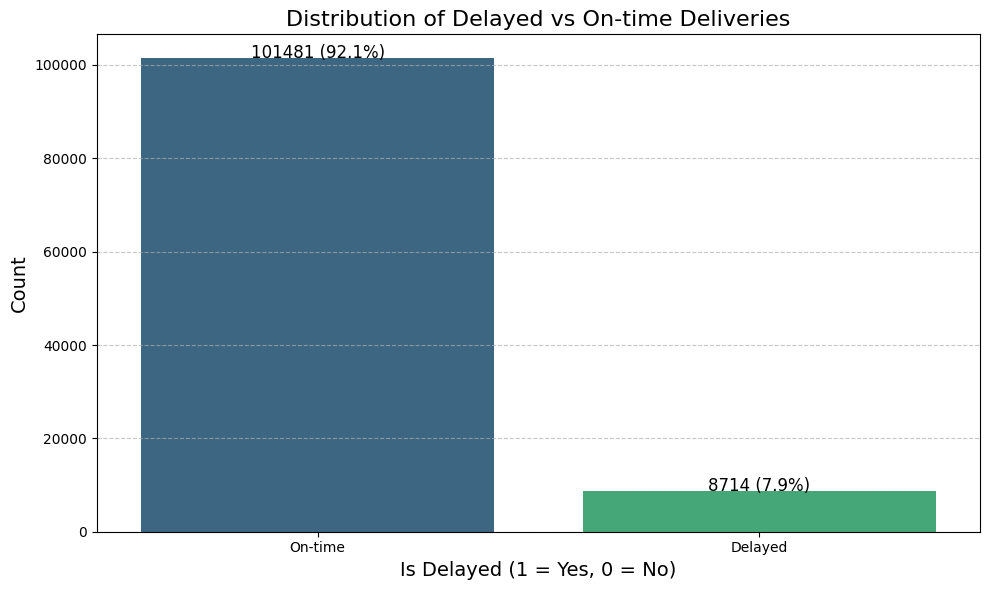

In [49]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='is_delayed', data=delivery_df, palette='viridis')
plt.title('Distribution of Delayed vs On-time Deliveries', fontsize=16)
plt.xlabel('Is Delayed (1 = Yes, 0 = No)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['On-time', 'Delayed'])
for i, count in enumerate(delivery_df['is_delayed'].value_counts()):
    plt.text(i, count + 100, f"{count} ({count/len(delivery_df):.1%})", 
             ha='center', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## B - Feature Engineering

In [50]:
# Create a copy for modeling
model_df = delivery_df.copy()

# Check available columns
print(f"Available columns: {model_df.columns.tolist()}")

# Extract temporal features
model_df['purchase_hour'] = model_df['order_purchase_timestamp'].dt.hour
model_df['purchase_day'] = model_df['order_purchase_timestamp'].dt.day
model_df['purchase_month'] = model_df['order_purchase_timestamp'].dt.month
model_df['purchase_year'] = model_df['order_purchase_timestamp'].dt.year
model_df['purchase_dayofweek'] = model_df['order_purchase_timestamp'].dt.dayofweek
model_df['purchase_weekend'] = (model_df['purchase_dayofweek'] >= 5).astype(int)

# Calculate distance between customer and seller (using zip code prefix as a proxy)
if 'seller_zip_code_prefix' in model_df.columns:
    model_df['zip_distance'] = abs(model_df['customer_zip_code_prefix'] - model_df['seller_zip_code_prefix'])
else:
    print("Warning: seller_zip_code_prefix not found. Please re-run cell 59 to load sellers data.")
    model_df['zip_distance'] = 0

# Calculate price per weight (handle division by zero)
model_df['price_per_weight'] = model_df['price'] / model_df['product_weight_g'].replace(0, 0.1)

# Create product volume feature
model_df['product_volume'] = (model_df['product_length_cm'] * 
                             model_df['product_height_cm'] * 
                             model_df['product_width_cm'])

# Handle infinite values
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Display the first few rows of the engineered features
print("\nSample of engineered features:")
model_df[['purchase_hour', 'purchase_day', 'purchase_month', 'purchase_year', 
          'purchase_dayofweek', 'purchase_weekend', 'zip_distance', 
          'price_per_weight', 'product_volume']].head()

Available columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'actual_delivery_time', 'estimated_delivery_time', 'is_delayed', 'time_to_carrier']

Sample of engineered features:


,purchase_hour,purchase_day,purchase_month,purchase_year,purchase_dayofweek,purchase_weekend,zip_distance,price_per_weight,product_volume
0,10,2,10,2017,0,0,6201,0.059980,1976.0
1,20,24,7,2018,1,0,16243,0.296750,4693.0
2,8,8,8,2018,2,0,60425,0.380714,9576.0
3,19,18,11,2017,5,1,27454,0.100000,6000.0
4,21,13,2,2018,1,0,443,0.079600,11475.0


## C - Exploratory Data Analysis for Feature Selection

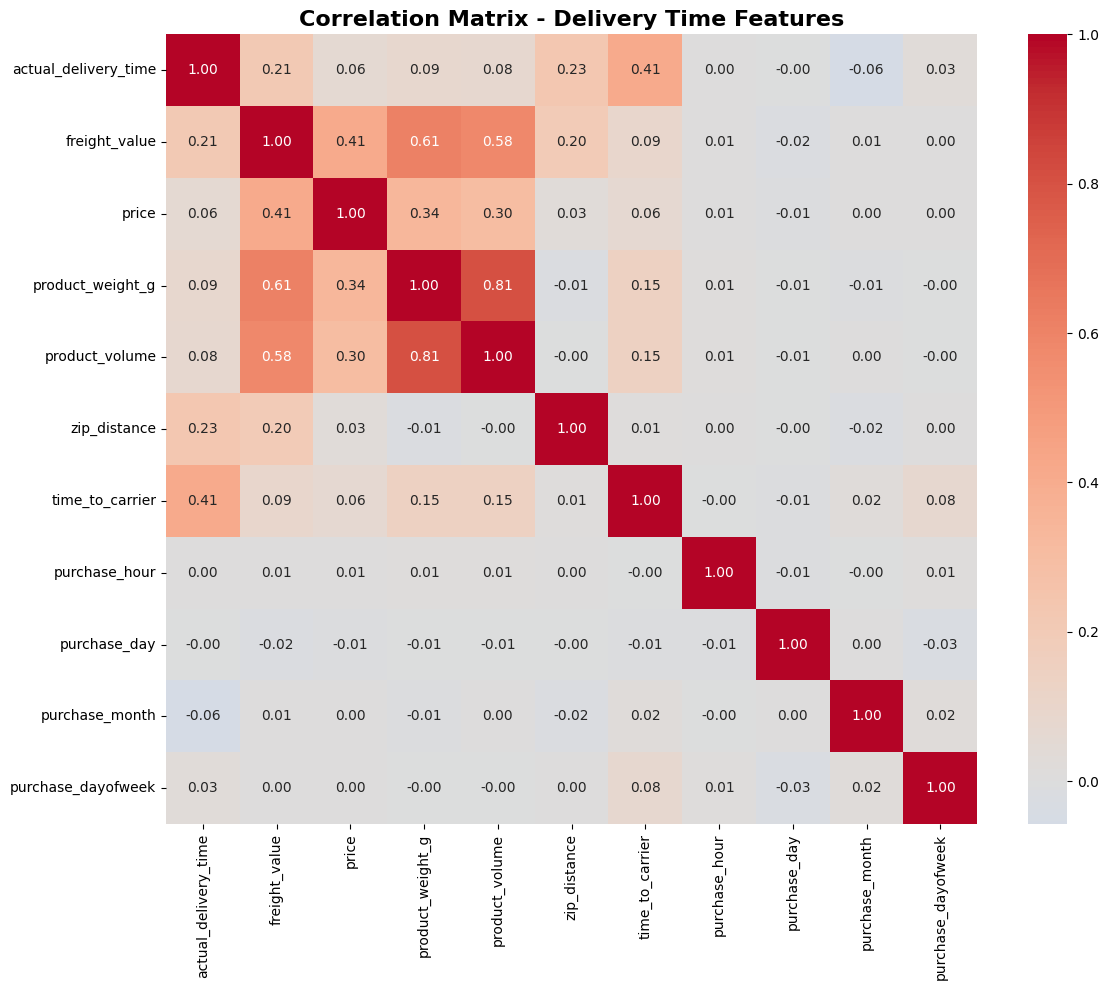


Correlation with actual_delivery_time:
actual_delivery_time    1.000000
time_to_carrier         0.408069
zip_distance            0.230450
freight_value           0.214717
product_weight_g        0.085677
product_volume          0.078201
price                   0.062383
purchase_dayofweek      0.029108
purchase_hour           0.002616
purchase_day           -0.001261
purchase_month         -0.057266
Name: actual_delivery_time, dtype: float64


In [51]:
# Analyze correlation between features and delivery time with a correlation matrix

# Select numeric features for correlation analysis
numeric_cols = ['actual_delivery_time', 'freight_value', 'price', 'product_weight_g',
                'product_volume', 'zip_distance', 'time_to_carrier',
                'purchase_hour', 'purchase_day', 'purchase_month', 'purchase_dayofweek']

correlation_matrix = model_df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Delivery Time Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlation with actual_delivery_time
print("\nCorrelation with actual_delivery_time:")
print(correlation_matrix['actual_delivery_time'].sort_values(ascending=False))


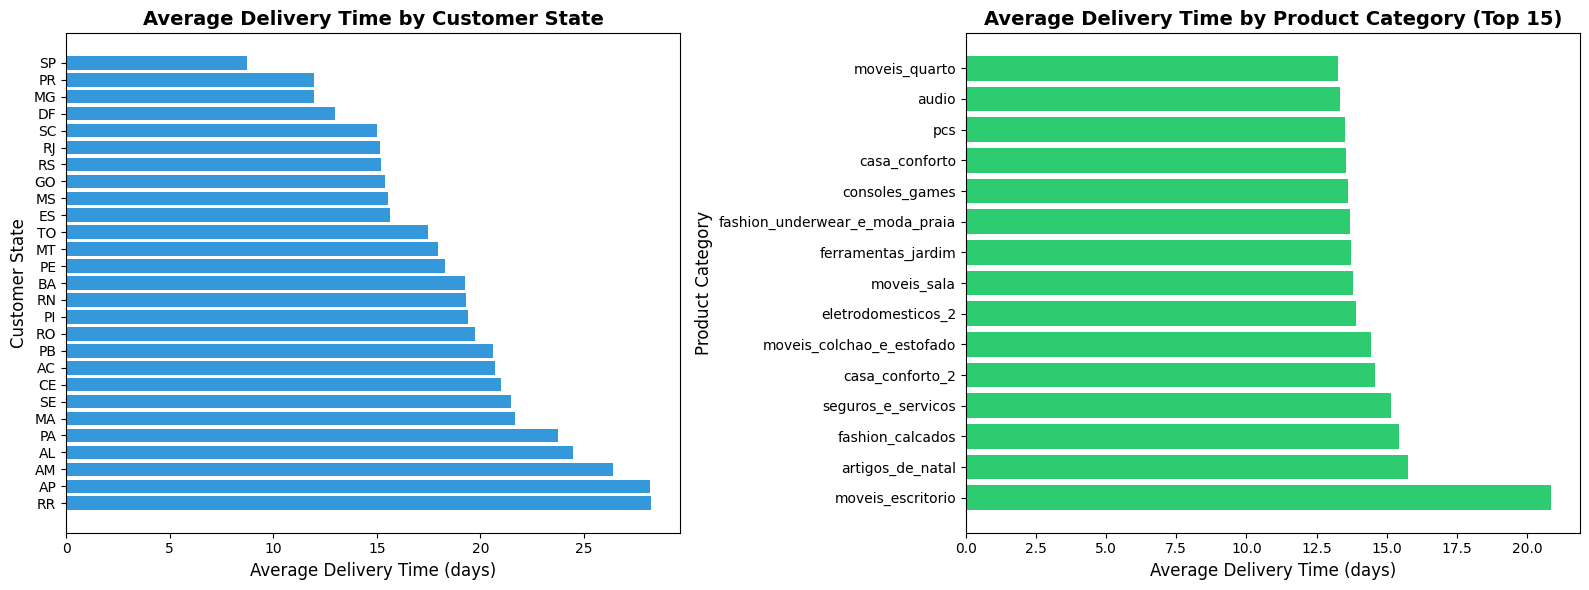

In [52]:
# Analyze categorical features
categorical_features = ['customer_state', 'product_category_name']

# compute the average delivery time for each of the categorical feature with a bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average delivery time by customer state
delivery_by_customer_state = model_df.groupby('customer_state')['actual_delivery_time'].mean().sort_values(ascending=False)
axes[0].barh(delivery_by_customer_state.index, delivery_by_customer_state.values, color='#3498DB')
axes[0].set_xlabel('Average Delivery Time (days)', fontsize=12)
axes[0].set_ylabel('Customer State', fontsize=12)
axes[0].set_title('Average Delivery Time by Customer State', fontsize=14, fontweight='bold')

# Average delivery time by top 15 product categories
delivery_by_category = model_df.groupby('product_category_name')['actual_delivery_time'].mean().sort_values(ascending=False).head(15)
axes[1].barh(delivery_by_category.index, delivery_by_category.values, color='#2ECC71')
axes[1].set_xlabel('Average Delivery Time (days)', fontsize=12)
axes[1].set_ylabel('Product Category', fontsize=12)
axes[1].set_title('Average Delivery Time by Product Category (Top 15)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## D - Feature Selection

In [53]:
# Select features based on correlation analysis and domain knowledge
selected_numeric_features = ['freight_value', 'price', 'product_weight_g', 
                            'product_volume', 'zip_distance', 'time_to_carrier',
                            'purchase_month', 'purchase_dayofweek']

# Select categorical features
selected_categorical_features = ['customer_state']


In [54]:
# Prepare feature and target variables
# Drop rows with NaN in selected features
model_df_clean = model_df.dropna(subset=selected_numeric_features + selected_categorical_features + ['actual_delivery_time'])

X_numeric = model_df_clean[selected_numeric_features]
X_categorical = model_df_clean[selected_categorical_features]
X_combined = pd.concat([X_numeric, X_categorical], axis=1)

# For regression task (predicting delivery time)
y_regression = model_df_clean['actual_delivery_time']

# Split the data
X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X_combined, y_regression, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train_reg.shape}")
print(f"Testing set shape: {X_test_reg.shape}")

Training set shape: (88141, 9)
Testing set shape: (22036, 9)


## E - Building the Regression Model (Predicting Delivery Time)

In [55]:
# Define preprocessing for numeric and categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, selected_numeric_features),
        ('cat', categorical_transformer, selected_categorical_features)
    ]
)

print("Preprocessor defined successfully!")


Preprocessor defined successfully!


In [56]:
# Create a Linear Regression Pipeline

lr_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train Linear Regression
lr_reg_pipeline.fit(X_train_reg, y_reg_train)
print("Linear Regression model trained successfully!")


Linear Regression model trained successfully!


In [57]:
# Make predictions based on your linear regression

y_pred_lr_reg = lr_reg_pipeline.predict(X_test_reg)

# Evaluate the model
mae_lr_reg = mean_absolute_error(y_reg_test, y_pred_lr_reg)
rmse_lr_reg = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr_reg))
r2_lr_reg = r2_score(y_reg_test, y_pred_lr_reg)

print(f"Linear Regression - MAE: {mae_lr_reg:.2f} days")
print(f"Linear Regression - RMSE: {rmse_lr_reg:.2f} days")
print(f"Linear Regression - R²: {r2_lr_reg:.2f}")


Linear Regression - MAE: 4.56 days
Linear Regression - RMSE: 7.30 days
Linear Regression - R²: 0.37


the R² should be about 0.40, which is not a good number. Can you do better with a Random Forest model, or any other model? 

Objective is to get a R² > 0.45!

## F - Building a Random Forest model

In [58]:
# Build a Random Forest Regressor model

rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

# Train the model
print("Training Random Forest Regressor...")
start_time = time.time()
rf_reg_pipeline.fit(X_train_reg, y_reg_train)
training_time = time.time() - start_time
print(f"Random Forest training completed in {training_time:.2f} seconds")

# Make predictions
y_pred_rf_reg = rf_reg_pipeline.predict(X_test_reg)

# Evaluate the model
mae_rf_reg = mean_absolute_error(y_reg_test, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg))
r2_rf_reg = r2_score(y_reg_test, y_pred_rf_reg)

print(f"\nRandom Forest Regressor Results:")
print(f"MAE: {mae_rf_reg:.2f} days")
print(f"RMSE: {rmse_rf_reg:.2f} days")
print(f"R²: {r2_rf_reg:.2f}")

# Compare with Linear Regression
print(f"\nImprovement over Linear Regression:")
print(f"R² improvement: {r2_rf_reg - r2_lr_reg:.4f}")

Training Random Forest Regressor...
Random Forest training completed in 10.67 seconds

Random Forest Regressor Results:
MAE: 3.99 days
RMSE: 6.80 days
R²: 0.46

Improvement over Linear Regression:
R² improvement: 0.0827


### G - Building a K-Nearest Neighbors model

In [59]:
# Build a K-Nearest Neighbors Regressor model

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=10, n_jobs=-1))
])

# Train the model
print("Training KNN Regressor...")
start_time = time.time()
knn_pipeline.fit(X_train_reg, y_reg_train)
training_time = time.time() - start_time
print(f"KNN training completed in {training_time:.2f} seconds")

# Make predictions
y_pred_knn = knn_pipeline.predict(X_test_reg)

# Evaluate the model
mae_knn = mean_absolute_error(y_reg_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_reg_test, y_pred_knn))
r2_knn = r2_score(y_reg_test, y_pred_knn)

print(f"\nKNN Regressor Results:")
print(f"MAE: {mae_knn:.2f} days")
print(f"RMSE: {rmse_knn:.2f} days")
print(f"R²: {r2_knn:.2f}")

# Final comparison
print("\n" + "="*50)
print("FINAL MODEL COMPARISON - Delivery Time Prediction")
print("="*50)
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("-"*50)
print(f"{'Linear Regression':<25} {mae_lr_reg:>10.2f} {rmse_lr_reg:>10.2f} {r2_lr_reg:>10.2f}")
print(f"{'Random Forest':<25} {mae_rf_reg:>10.2f} {rmse_rf_reg:>10.2f} {r2_rf_reg:>10.2f}")
print(f"{'K-Nearest Neighbors':<25} {mae_knn:>10.2f} {rmse_knn:>10.2f} {r2_knn:>10.2f}")
print("="*50)

# Determine best model
best_r2 = max(r2_lr_reg, r2_rf_reg, r2_knn)
if best_r2 == r2_rf_reg:
    print("Best model: Random Forest")
elif best_r2 == r2_knn:
    print("Best model: K-Nearest Neighbors")
else:
    print("Best model: Linear Regression")

Training KNN Regressor...
KNN training completed in 0.07 seconds

KNN Regressor Results:
MAE: 4.27 days
RMSE: 7.16 days
R²: 0.40

FINAL MODEL COMPARISON - Delivery Time Prediction
Model                            MAE       RMSE         R²
--------------------------------------------------
Linear Regression               4.56       7.30       0.37
Random Forest                   3.99       6.80       0.46
K-Nearest Neighbors             4.27       7.16       0.40
Best model: Random Forest
